In [1]:
from ProjectFunctions import *

# Generating NetworkX Visualizations

In [2]:
#generate the instance and find the groundstate
length = 8
Hfield = sg_field(length)
jij = generate_jij(length, 14, 5001)
Hint, Hintdiag = sg_interaction(length, jij)
H = Hint + (0.01 * Hfield)
E, psi = H.groundstate()
hamming_distance(length, Hintdiag)

The hamming distance is 4 for states 00100110 and 01001100
The hamming distance is 4 for states 00100110 and 10110011
The hamming distance is 4 for states 01001100 and 11011001
The hamming distance is 4 for states 10110011 and 11011001


In [3]:
#calculate the mutual information and mutual information distances
minfolist = []
distlist = []
for i in range(length):
    for j in range(i + 1, length):
        minfo, distance = mutual_info(length, psi, [i], [j])
        distlist.append(distance)
        minfolist.append(minfo)

In [4]:
# Generate all possible pairs of positions
combinations = []
for i in range(length):
    for j in range(i + 1, length):
        combinations.append([i, j])

In [5]:
# Create a NetworkX graph
G = nx.Graph()

# Add edges with weights for every connection between nodes
#The mutual information distance is used as the edge weight
for [i, j], dist in zip(combinations, distlist):
    G.add_edge(i, j, weight = minfo)


#find the shortest path lengths and the directions through nodes to traverse shortest paths    
path = dict(nx.all_pairs_dijkstra_path(G, cutoff=None, weight='weight'))
lengths = dict(nx.all_pairs_dijkstra_path_length(G, cutoff=None, weight='weight'))

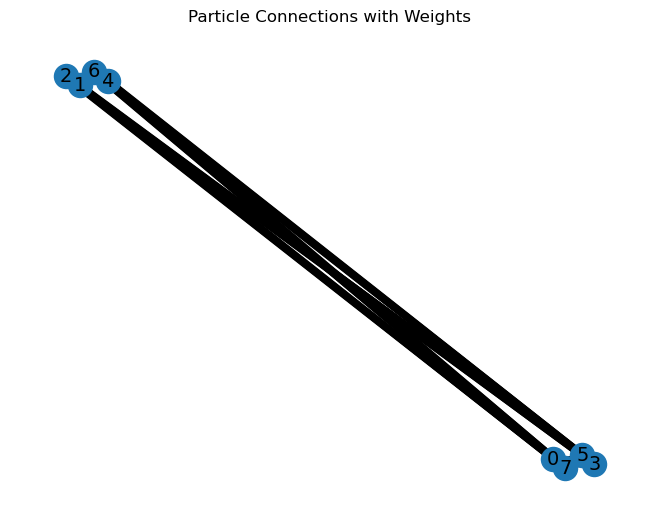

In [6]:
#generate positions for nodes according to a particular model included in NetworkX
pos = nx.kamada_kawai_layout(G)
#create edge weights for graph
edge_weights = nx.get_edge_attributes(G, 'weight')
#correspond edge thickness to the edge weights
edge_thickness = [weight/8 for weight in edge_weights.values()]

# Draw the graph with varying edge thickness
nx.draw(G, pos, with_labels=True, node_size=300, font_size=14)
nx.draw_networkx_edges(G, pos, width=edge_thickness)

# Show the plot
plt.title("Particle Connections with Weights")
plt.show()

# Use sklearn to Identify Clusters and Visualize the Affinity Matrix

In [7]:
#create the affinity matrix from the mutual information values
affmat = create_affinity_matrix(length, combinations, minfolist)
#use sklearn to identify clusters from the affinity matrix
clusterObj = skl.cluster.SpectralClustering(n_clusters = 2, affinity = 'precomputed')
clusters = clusterObj.fit_predict(affmat)
print(clusters)

C:\Users\danny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[0 1 1 0 1 0 1 0]


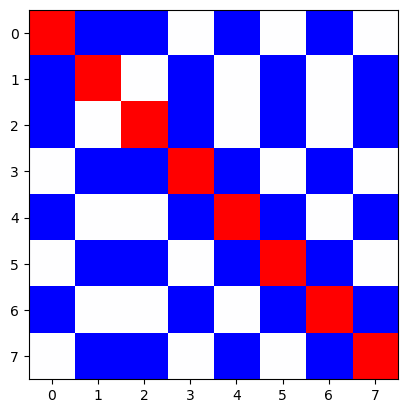

In [8]:
#visualize the affinity matrix
plt.imshow(affmat, cmap='bwr')

In [9]:
#block diagonalize the affinity matrix by rearranging by cluster
new_order, new_affmat = rearrange_affmat(affmat, clusters)
print(new_order)

[0, 3, 5, 7, 1, 2, 4, 6]


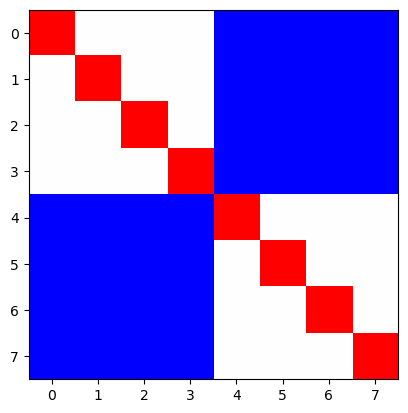

In [10]:
#visualize the block diagonalized matrix
plt.imshow(new_affmat, cmap='bwr')

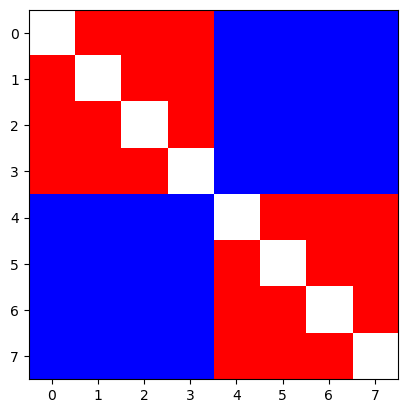

In [12]:
# Mask the diagonal by setting it to NaN, as it is much larger than the other values
masked_affmat = np.copy(new_affmat)
np.fill_diagonal(masked_affmat, np.nan)

# Find the min and max of the off-diagonal elements for normalization
min_val = np.nanmin(masked_affmat)
max_val = np.nanmax(masked_affmat)
#show the new masked visualization
plt.imshow(masked_affmat, cmap='bwr')